In [2]:
import sys
import os
import pandas as pd
import numpy as np
import logging
import yfinance as yf

# Point this to your main package directory
parent_path = os.path.abspath("E:\\SOM_trading\\som_algo_trading\\som_algo_trading")
if parent_path not in sys.path:
    sys.path.append(parent_path)

from som_algo_trading import SOMTradingPipeline, TradingConfig
from som_algo_trading.utils import (
    setup_logging,
    backtest_summary,
    plot_u_matrix,
    plot_cluster_signals,
    plot_equity_curve,
)

In [3]:
df = yf.download("RELIANCE.NS", start="2020-01-01", end="2024-01-01")
setup_logging(level=logging.INFO)

prices_array = df['Close'].dropna().to_numpy().flatten()

[*********************100%***********************]  1 of 1 completed


In [31]:
# Configure the Pipeline for Real Data
# config = TradingConfig(
#     window_size=25,     # 30-day memory
#     grid_rows=10,       
#     grid_cols=10,       # 100 historical regime folders
#     num_iterations=10000, 
#     train_ratio=0.80,   # 80% history for training, 20% unseen data for testing
#     win_rate_threshold=0.60
# )

config = TradingConfig(
    window_size=20,           # Shorten the memory to 1 month of trading days
    grid_rows=10,       
    grid_cols=10,       
    num_iterations=10000, 
    train_ratio=0.80,   
    
    # --- LOOSEN THE RESTRICTIONS --- #
    win_rate_threshold=0.52,  # Drop to 52% (a slight statistical edge)
    min_cluster_samples=8,    # Require only 8 historical examples to take a trade
    anomaly_percentile=99.0   # Only halt the system on the top 1% craziest days
)

print("\nInitializing and Training SOM Trading Pipeline...")
pipeline = SOMTradingPipeline(config)

# This triggers Phase 1 (Data Prep) and Phase 2 (SOM Training)
pipeline.fit(prices_array)


Initializing and Training SOM Trading Pipeline...
2026-04-11 22:14:04 | INFO     | som_algo_trading.pipeline | === SOMTradingPipeline.fit() START ===
2026-04-11 22:14:04 | INFO     | som_algo_trading.pipeline | Phase 1 — Data Engineering
2026-04-11 22:14:04 | INFO     | som_algo_trading.data | DataEngineer fitted | prices=992  windows=970  train=776  test=194
2026-04-11 22:14:04 | INFO     | som_algo_trading.pipeline | Phase 2 — SOM Training
2026-04-11 22:14:04 | INFO     | som_algo_trading.som | Initialising SOM weights via PCA (10x10, sigma=3.00, lr=0.500) ...
2026-04-11 22:14:04 | INFO     | som_algo_trading.som | Training SOM for 10000 iterations ...
2026-04-11 22:14:04 | INFO     | som_algo_trading.som | SOM training complete.
2026-04-11 22:14:04 | INFO     | som_algo_trading.som | Cluster map built | 776 windows → 100 / 100 nodes used
2026-04-11 22:14:04 | INFO     | som_algo_trading.inference | Anomaly threshold set to 13.7165 (99th percentile of training QEs).
2026-04-11 22:14

SOMTradingPipeline(status=fitted, config=TradingConfig(
  window_size            = 20
  grid               = 10x10 (100 nodes)
  sigma                  = 3.0
  learning_rate          = 0.5
  num_iterations         = 10,000
  anomaly_threshold      = None
  anomaly_percentile     = 99.0
  min_cluster_samples    = 8
  win_rate_threshold     = 0.52
  expected_return_thresh = 0.001
  train_ratio            = 0.8
  random_state           = 42
))

In [32]:
print("\nRunning Walk-Forward Backtest on Unseen Test Set...")
bt_results = pipeline.backtest()

# Use your utils file to print a clean summary
backtest_summary(bt_results)

print("\n-----------------------------------------")
print("Running Live Inference (Tomorrow's Forecast)")
print("-----------------------------------------")

# Extract exactly enough recent data to form one final window
recent_prices = prices_array[-(config.window_size + 1):]

# This triggers Phase 3 (Risk Gate) and Phase 4 (Forecasting)
live_forecast = pipeline.predict(recent_prices)

print(f"SIGNAL: {live_forecast.signal}")
if live_forecast.reason:
    print(f"Notes:  {live_forecast.reason}")


Running Walk-Forward Backtest on Unseen Test Set...
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(5), np.int64(1)) has only 6 historical matches (minimum required: 8).
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(3), np.int64(2)) has only 5 historical matches (minimum required: 8).
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | SELL | BMU=(np.int64(0), np.int64(5)) | E[r]=-0.0066 | WR=0.45 | n=11
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | BUY | BMU=(np.int64(1), np.int64(0)) | E[r]=0.0114 | WR=0.70 | n=10
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(5), np.int64(6)) has only 7 historical matches (minimum required: 8).
2026-04-11 22:14:07 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(6), np.int64(7)) has only 7 historical matches (minimum required: 8).
2026-04-11 22:14:07 | INFO     | som_algo_trading.f


Generating visualisations ...


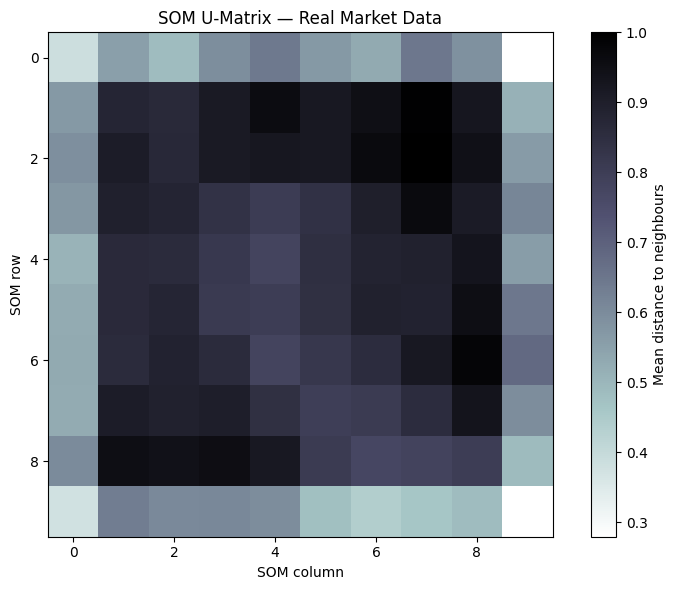

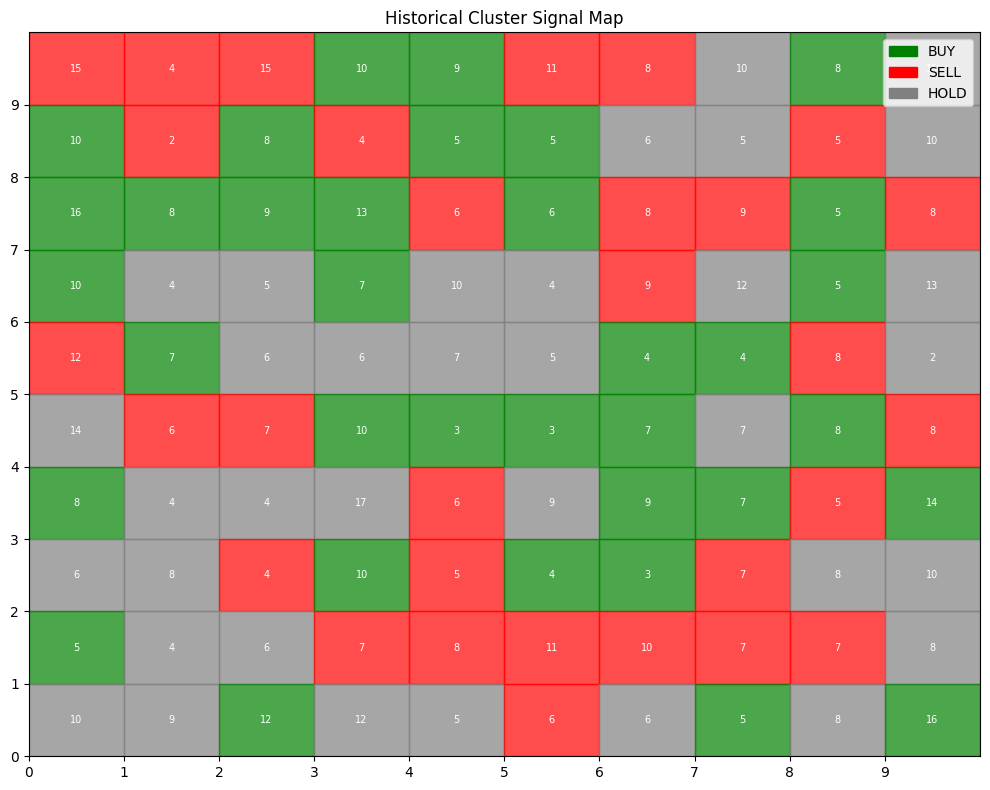

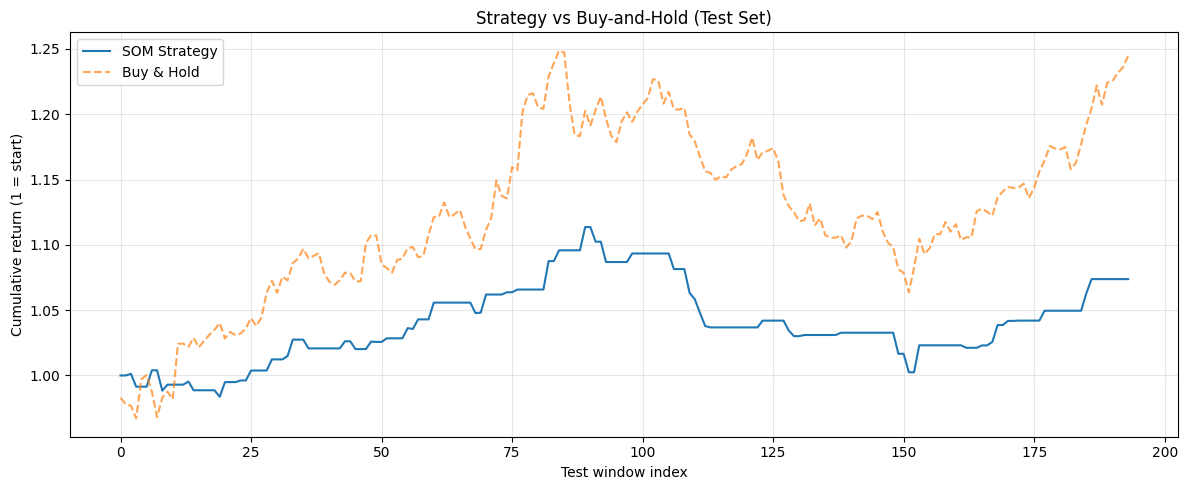

In [33]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

if HAS_MPL:
    print("\nGenerating visualisations ...")
    
    # 1. The U-Matrix shows the topological distance between your real market regimes
    plot_u_matrix(pipeline.som_core, title="SOM U-Matrix — Real Market Data")
    
    # 2. The Cluster Signal Map shows where the high-probability Buy/Sell zones live
    plot_cluster_signals(
        pipeline.forecaster,
        grid_rows=config.grid_rows,
        grid_cols=config.grid_cols,
        title="Historical Cluster Signal Map",
    )
    
    # 3. The Equity Curve compares the algorithm vs. Buy-and-Hold on the Test Set
    plot_equity_curve(bt_results, title="Strategy vs Buy-and-Hold (Test Set)")
else:
    print("Matplotlib not installed. Skipping visualisations.")